In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# Function to convert Excel serial date to datetime (if needed)
def excel_to_datetime(serial):
    try:
        serial = int(serial)
        return datetime(1899, 12, 30) + timedelta(days=serial)
    except:
        return pd.NaT

In [3]:
# Step 2: Load and Inspect KSE Data (unchanged)
file_path = 'kse-30-basic.xlsx'
df_org = pd.read_excel(file_path)
df = df_org.copy()
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = df['date'].apply(excel_to_datetime)
df = df.dropna(subset=['date', 'company', 'price', 'idx_wt_%', 'volume'])
df = df.sort_values(['date', 'company']).reset_index(drop=True)
df_cleaned = df.copy()

In [4]:
df_cleaned.head()

,date,symbol,company,price,idx_wt_%,volume
0,2020-01-01,BAHL,Bank Al-Habib Ltd.,77.33,4.29,257500
1,2020-01-01,BAFL,Bank Alfalah Ltd.,46.74,2.55,1128000
2,2020-01-01,BOP,Bank Of Punjab.,11.73,1.01,7507000
3,2020-01-01,DGKC,D. G. Khan Cement Co. Ltd.,75.23,1.27,1501000
4,2020-01-01,ENGRO,Engro Corporation Limited.,354.28,8.63,231900


In [5]:
# Compute daily aggregates
df_cleaned['weighted_price'] = df_cleaned['price'] * df_cleaned['idx_wt_%']
daily_agg = df_cleaned.groupby('date').agg(
    total_volume=('volume', 'sum'),
    weighted_return=('weighted_price', 'sum')
).reset_index()

In [6]:
df_cleaned.head()

,date,symbol,company,price,idx_wt_%,volume,weighted_price
0,2020-01-01,BAHL,Bank Al-Habib Ltd.,77.33,4.29,257500,331.7457
1,2020-01-01,BAFL,Bank Alfalah Ltd.,46.74,2.55,1128000,119.1870
2,2020-01-01,BOP,Bank Of Punjab.,11.73,1.01,7507000,11.8473
3,2020-01-01,DGKC,D. G. Khan Cement Co. Ltd.,75.23,1.27,1501000,95.5421
4,2020-01-01,ENGRO,Engro Corporation Limited.,354.28,8.63,231900,3057.4364


In [7]:
daily_agg.head()

,date,total_volume,weighted_return
0,2020-01-01,55169900,21114.9944
1,2020-01-02,151334700,21553.9228
2,2020-01-03,130968430,21457.5729
3,2020-01-06,96604890,20966.0359
4,2020-01-07,70796630,21329.3670


In [8]:
# Resample to monthly
daily_agg['date'] = pd.to_datetime(daily_agg['date'])
daily_agg.set_index('date', inplace=True)
monthly_df = daily_agg.resample('ME').agg({
    'total_volume': 'sum',
    'weighted_return': 'mean'
}).reset_index()

monthly_df['log_return'] = np.log(monthly_df['weighted_return'] / monthly_df['weighted_return'].shift(1))

In [9]:
monthly_df.head()

,date,total_volume,weighted_return,log_return
0,2020-01-31,2173067550,21788.892100,NaN
1,2020-02-29,1224806920,20260.168042,-0.072744
2,2020-03-31,2110137290,17200.543614,-0.163716
3,2020-04-30,2027859811,17004.016473,-0.011491
4,2020-05-31,1143466534,18689.350125,0.094504


In [10]:
# Load and process funds_data for flows
fund_sheets = ['AKD', 'NBP', 'NTI']
fund_flows = []
for sheet in fund_sheets:
    fund_df = pd.read_excel('funds_data.xlsx', sheet_name=sheet)
    fund_df.columns = fund_df.columns.str.lower().str.strip().str.replace(' ', '_')
    if not pd.api.types.is_datetime64_any_dtype(fund_df['date']):
        fund_df['date'] = fund_df['date'].apply(excel_to_datetime)
    fund_df = fund_df.dropna(subset=['date', 'nav', 'aum'])
    fund_df = fund_df.sort_values('date').reset_index(drop=True)
    fund_df['nav_ratio'] = fund_df['nav'] / fund_df['nav'].shift(1)
    fund_df['flow'] = fund_df['aum'] - (fund_df['aum'].shift(1) * fund_df['nav_ratio'])
    fund_df['flow'] = fund_df['flow'].fillna(0)
    fund_flows.append(fund_df[['date', 'flow']])

all_fund_flows = pd.concat(fund_flows)
all_fund_flows = all_fund_flows.groupby('date')['flow'].sum().reset_index()
all_fund_flows['date'] = pd.to_datetime(all_fund_flows['date'])
all_fund_flows.set_index('date', inplace=True)
total_monthly_flow = all_fund_flows.resample('ME')['flow'].sum().reset_index(name='total_fund_flow')

In [11]:
all_fund_flows.head()

,flow
date,
2020-03-18,0.000000
2020-03-24,0.239999
2020-03-25,0.489966
2020-03-26,0.340733
2020-03-27,-0.034697


In [12]:
total_monthly_flow.head()

,date,total_fund_flow
0,2020-03-31,0.876717
1,2020-04-30,35.484107
2,2020-05-31,-1.618847
3,2020-06-30,3.255424
4,2020-07-31,-0.899210


In [13]:
# Load and process macro_data
oil_df = pd.read_excel('macro_data.xlsx', sheet_name='OIL')
oil_df.columns = oil_df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(oil_df['date']):
    oil_df['date'] = oil_df['date'].apply(excel_to_datetime)
oil_df = oil_df.dropna(subset=['date'])
oil_df = oil_df.groupby('date')['price'].mean().reset_index()
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df.set_index('date', inplace=True)
monthly_oil = oil_df.resample('ME')['price'].mean().reset_index(name='oil_price')

In [14]:
oil_df.head()

,price
date,
2021-01-04,51.09
2021-01-05,53.60
2021-01-06,54.30
2021-01-07,54.38
2021-01-08,55.99


In [15]:
monthly_oil.head()

,date,oil_price
0,2021-01-31,55.321500
1,2021-02-28,62.281500
2,2021-03-31,65.702174
3,2021-04-30,65.328571
4,2021-05-31,68.309048


In [16]:
ir_df = pd.read_excel('macro_data.xlsx', sheet_name='IR')
ir_df.columns = ir_df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(ir_df['date']):
    ir_df['date'] = ir_df['date'].apply(excel_to_datetime)
ir_df = ir_df.dropna(subset=['date'])
ir_df = ir_df.groupby('date')['rate'].last().reset_index()
ir_df['date'] = pd.to_datetime(ir_df['date'])
ir_df.set_index('date', inplace=True)
ir_df.sort_index(inplace=True)
daily_index = pd.date_range(start=ir_df.index.min(), end=ir_df.index.max(), freq='D')
ir_df = ir_df.reindex(daily_index).ffill()
monthly_ir = ir_df.resample('ME')['rate'].last().reset_index()
if 'index' in monthly_ir.columns:
    monthly_ir.rename(columns={'index': 'date'}, inplace=True)
monthly_ir.rename(columns={'rate': 'interest_rate'}, inplace=True)

In [17]:
ir_df.head()

,rate
2021-09-21,7.25
2021-09-22,7.25
2021-09-23,7.25
2021-09-24,7.25
2021-09-25,7.25


In [18]:
monthly_ir.head()

,date,interest_rate
0,2021-09-30,7.25
1,2021-10-31,7.25
2,2021-11-30,8.75
3,2021-12-31,9.75
4,2022-01-31,9.75


In [19]:
usd_df = pd.read_excel('macro_data.xlsx', sheet_name='USD')
usd_df.columns = usd_df.columns.str.lower().str.strip().str.replace(' ', '_')
if not pd.api.types.is_datetime64_any_dtype(usd_df['date']):
    usd_df['date'] = usd_df['date'].apply(excel_to_datetime)
usd_df = usd_df.dropna(subset=['date'])
usd_df = usd_df.groupby('date')['usd'].mean().reset_index()
usd_df['date'] = pd.to_datetime(usd_df['date'])
usd_df.set_index('date', inplace=True)
monthly_usd = usd_df.resample('ME')['usd'].mean().reset_index(name='usd_exchange')

In [20]:
usd_df.head()

,usd
date,
2021-03-01,159.98
2021-03-02,160.33
2021-03-03,160.29
2021-03-04,160.01
2021-03-07,160.17


In [21]:
monthly_usd.head()

,date,usd_exchange
0,2021-03-31,160.369091
1,2021-04-30,159.028421
2,2021-05-31,156.388235
3,2021-06-30,153.340000
4,2021-07-31,153.535556


In [22]:
# Merge to enhanced monthly df
enhanced_monthly = monthly_df.merge(total_monthly_flow, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_oil, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_ir, on='date', how='left')
enhanced_monthly = enhanced_monthly.merge(monthly_usd, on='date', how='left')

# Fund flow: months before fund data starts have no flow — treat as 0
enhanced_monthly['total_fund_flow'] = enhanced_monthly['total_fund_flow'].fillna(0)

# Macro columns: ffill only (bfill removed — 2020 rows will be dropped below)
enhanced_monthly[['oil_price', 'interest_rate', 'usd_exchange']] = (
    enhanced_monthly[['oil_price', 'interest_rate', 'usd_exchange']]
    .ffill()
)

# log_return for the first row is NaN (no prior month) — fill with 0
enhanced_monthly['log_return'] = enhanced_monthly['log_return'].fillna(0)

In [23]:
enhanced_monthly.shape

(70, 8)

In [24]:
# Winsorize total_fund_flow at ±3 standard deviations
# The April 2022 outlier (-62.7) is a one-off political event, not a learnable pattern
mean_flow = enhanced_monthly['total_fund_flow'].mean()
std_flow = enhanced_monthly['total_fund_flow'].std()
lower_bound = mean_flow - 3 * std_flow
upper_bound = mean_flow + 3 * std_flow
enhanced_monthly['total_fund_flow'] = enhanced_monthly['total_fund_flow'].clip(lower=lower_bound, upper=upper_bound)
print(f"Winsorize bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Flow range after winsorize: [{enhanced_monthly['total_fund_flow'].min():.2f}, {enhanced_monthly['total_fund_flow'].max():.2f}]")

Winsorize bounds: [-723.17, 671.55]
Flow range after winsorize: [-723.17, 634.17]


In [25]:
# Suggestion 1: Drop 2020 rows
# Macro data starts 2021; all 2020 macro values were forward-filled from the
# earliest 2021 observation — fabricated values for oil, interest rate, USD.
# Training on fabricated flat macro values corrupts the model.
enhanced_monthly = enhanced_monthly[
    enhanced_monthly['date'].dt.year >= 2021
].reset_index(drop=True)
print(f"Rows after dropping 2020: {len(enhanced_monthly)}")
print(f"Date range: {enhanced_monthly['date'].min().date()} -> {enhanced_monthly['date'].max().date()}")

Rows after dropping 2020: 58
Date range: 2021-01-31 -> 2025-10-31


In [26]:
enhanced_monthly.shape

(58, 8)

In [27]:
enhanced_monthly.head(10)

,date,total_volume,weighted_return,log_return,total_fund_flow,oil_price,interest_rate,usd_exchange
0,2021-01-31,3027237081,22011.333519,0.023810,-24.194609,55.321500,NaN,NaN
1,2021-02-28,2708411348,24233.102611,0.096162,0.695951,62.281500,NaN,NaN
2,2021-03-31,2564601511,25308.350768,0.043415,-1.751042,65.702174,NaN,160.369091
3,2021-04-30,1544332690,25595.049295,0.011265,-1.761818,65.328571,NaN,159.028421
4,2021-05-31,1483879478,25726.611587,0.005127,-1.299179,68.309048,NaN,156.388235
5,2021-06-30,1830472979,26112.068423,0.014872,12.403225,73.408182,NaN,153.340000
6,2021-07-31,837970904,26162.647432,0.001935,-0.676629,74.293636,NaN,153.535556
7,2021-08-31,790705156,26001.171800,-0.006191,5.454506,70.513636,NaN,156.486190
8,2021-09-30,1189425792,26121.411657,0.004614,-6.142414,74.876364,7.25,160.465000
9,2021-10-31,1109948642,20503.668953,-0.242152,5.158895,83.746190,7.25,164.958000


In [28]:
# Lagged level features
enhanced_monthly['lag_volume'] = enhanced_monthly['total_volume'].shift(1)
enhanced_monthly['lag_return'] = enhanced_monthly['log_return'].shift(1)
enhanced_monthly['lag_oil'] = enhanced_monthly['oil_price'].shift(1)
enhanced_monthly['lag_ir'] = enhanced_monthly['interest_rate'].shift(1)
enhanced_monthly['lag_usd'] = enhanced_monthly['usd_exchange'].shift(1)

# Suggestion 2: First-difference features
# Direction of IR and USD change is more stationary across macro regimes than levels.
# Compute diff first, then lag by 1 — only information available at t-1 used.
enhanced_monthly['ir_change'] = enhanced_monthly['interest_rate'].diff()
enhanced_monthly['usd_pct_change'] = enhanced_monthly['usd_exchange'].pct_change()
enhanced_monthly['lag_ir_change'] = enhanced_monthly['ir_change'].shift(1)
enhanced_monthly['lag_usd_pct_change'] = enhanced_monthly['usd_pct_change'].shift(1)

enhanced_monthly = enhanced_monthly.dropna()

In [29]:
enhanced_monthly.head()

,date,total_volume,weighted_return,log_return,total_fund_flow,oil_price,interest_rate,usd_exchange,lag_volume,lag_return,lag_oil,lag_ir,lag_usd,ir_change,usd_pct_change,lag_ir_change,lag_usd_pct_change
10,2021-11-30,1326728643,27125.739035,0.279879,-1.287450,80.849545,8.75,168.872381,1.109949e+09,-0.242152,83.746190,7.25,164.958000,1.5,0.023730,0.0,0.028000
11,2021-12-31,1254134269,25642.342091,-0.056238,10.426701,74.803913,9.75,171.944762,1.326729e+09,0.279879,80.849545,8.75,168.872381,1.0,0.018194,1.5,0.023730
12,2022-01-31,1153450861,26095.913300,0.017534,-0.075819,85.572381,9.75,174.203333,1.254134e+09,-0.056238,74.803913,9.75,171.944762,0.0,0.013135,1.0,0.018194
13,2022-02-28,840632635,25810.757540,-0.010987,-2.163321,94.101500,9.75,177.669500,1.153451e+09,0.017534,85.572381,9.75,174.203333,0.0,0.019897,0.0,0.013135
14,2022-03-31,1078135764,25999.165195,0.007273,-13.720980,112.463043,9.75,176.471818,8.406326e+08,-0.010987,94.101500,9.75,177.669500,0.0,-0.006741,0.0,0.019897


In [30]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# Suggestion 3: Ridge replaces Random Forest
# Ridge + StandardScaler: low variance, handles correlated macro features,
# interpretable coefficients, no overfitting risk on ~50 rows.
features = ['lag_volume', 'lag_return', 'lag_oil', 'lag_ir', 'lag_usd',
            'lag_ir_change', 'lag_usd_pct_change']
X = enhanced_monthly[features]
y = enhanced_monthly['total_fund_flow']

tscv = TimeSeriesSplit(n_splits=5)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

fold_rmses = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_pipeline.fit(X_train, y_train)
    preds = ridge_pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    fold_rmses.append(rmse)
    print(f'Fold {fold} | test rows: {len(y_test)} | RMSE: {rmse:.4f}')

print(f'\nMean RMSE across folds: {np.mean(fold_rmses):.4f}')
print(f'Std  RMSE across folds: {np.std(fold_rmses):.4f}')

# Refit on full data for next-month prediction
ridge_pipeline.fit(X, y)
last_row = enhanced_monthly.iloc[-1][features].values.reshape(1, -1)
next_pred = ridge_pipeline.predict(last_row)
print(f'\nPredicted next fund flow: {next_pred[0]:.4f}')
# Suggestion 4: treat as directional signal only — not the magnitude
print('Note: use directional signal only — magnitude is unreliable at this dataset size')

Fold 1 | test rows: 8 | RMSE: 34.9537
Fold 2 | test rows: 8 | RMSE: 22.2033
Fold 3 | test rows: 8 | RMSE: 339.5461
Fold 4 | test rows: 8 | RMSE: 52.4015
Fold 5 | test rows: 8 | RMSE: 253.4186

Mean RMSE across folds: 140.5046
Std  RMSE across folds: 130.5875

Predicted next fund flow: -9.4281
Note: use directional signal only — magnitude is unreliable at this dataset size


d:\roohan\indexfund\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


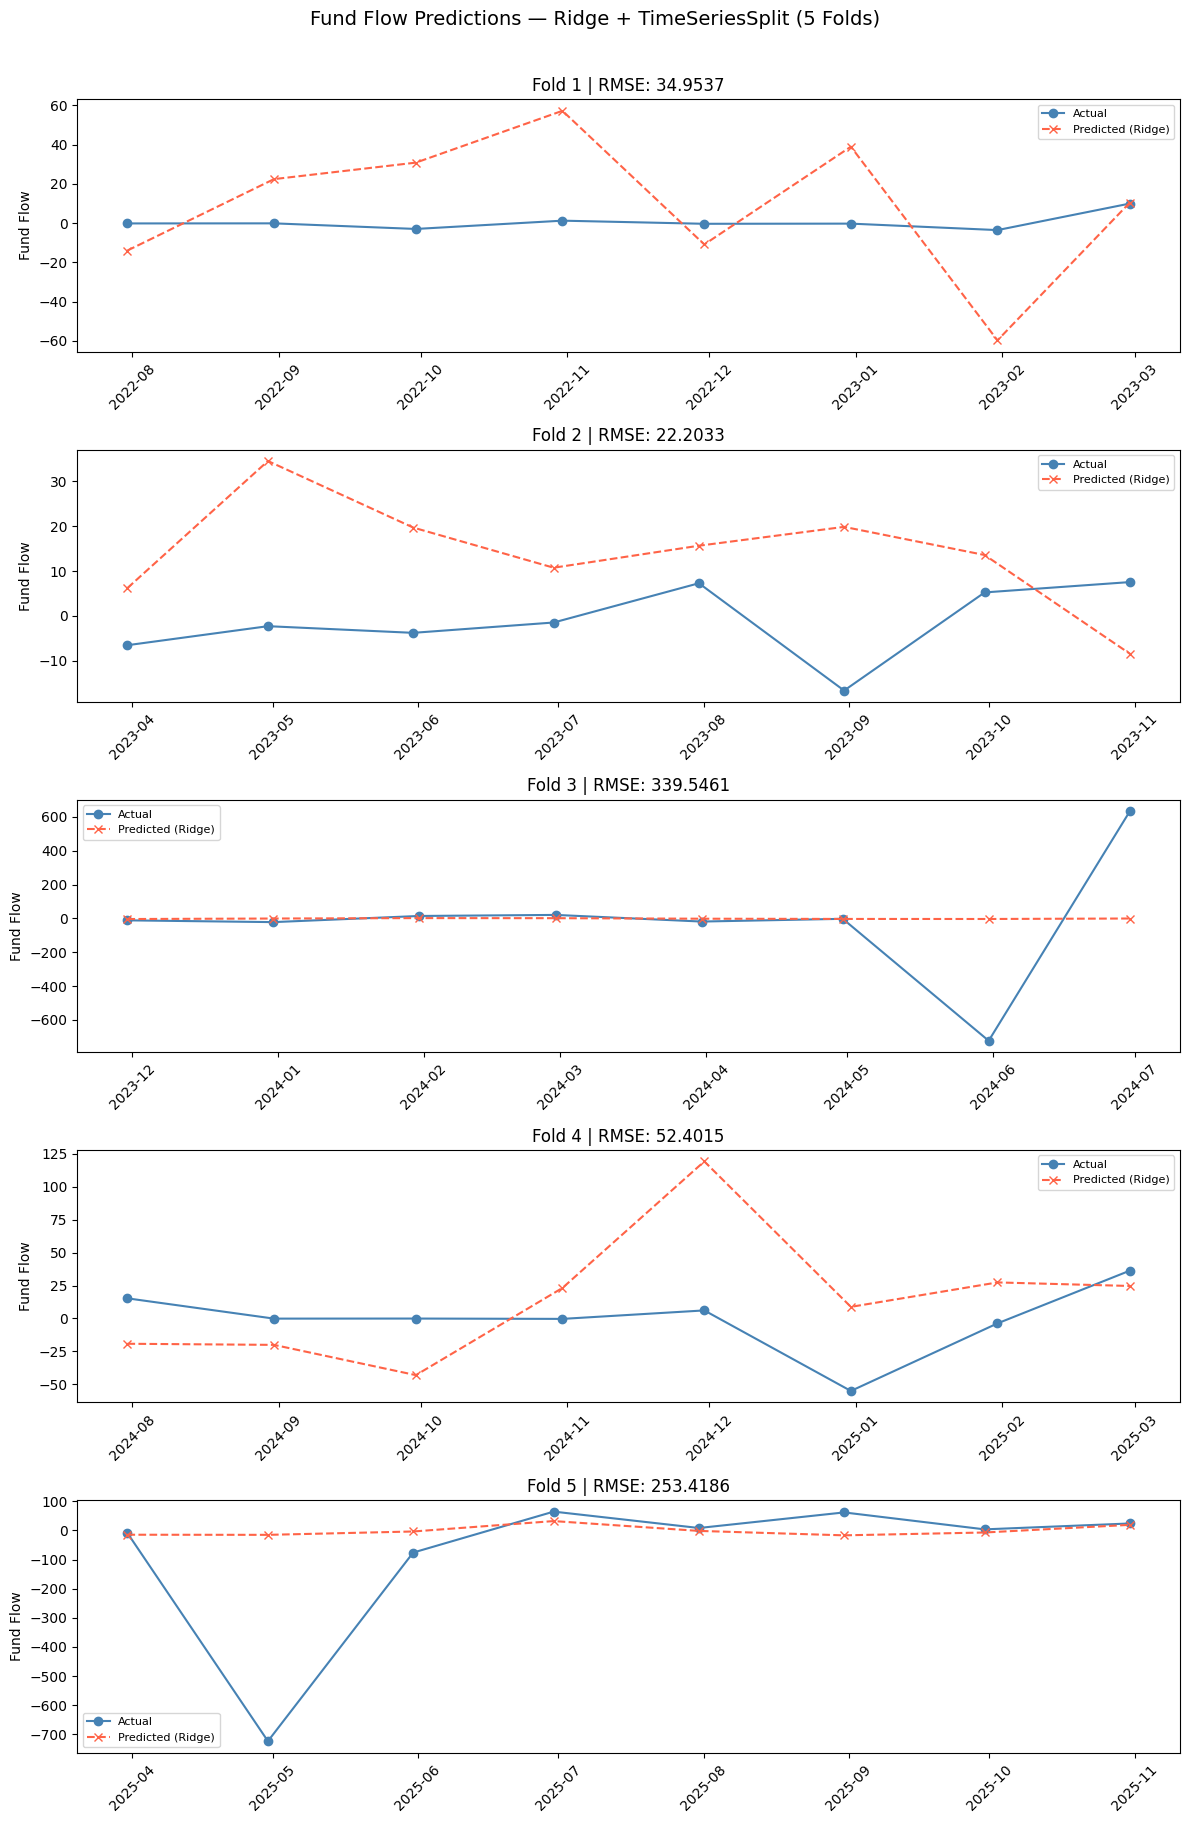

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=False)
fig.suptitle('Fund Flow Predictions — Ridge + TimeSeriesSplit (5 Folds)', fontsize=14, y=1.01)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_plot = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    ridge_plot.fit(X_train, y_train)
    preds = ridge_plot.predict(X_test)

    ax = axes[fold - 1]
    ax.plot(enhanced_monthly['date'].iloc[test_idx], y_test.values,
            marker='o', label='Actual', color='steelblue')
    ax.plot(enhanced_monthly['date'].iloc[test_idx], preds,
            marker='x', linestyle='--', label='Predicted (Ridge)', color='tomato')
    ax.set_title(f'Fold {fold} | RMSE: {fold_rmses[fold-1]:.4f}')
    ax.set_ylabel('Fund Flow')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# Portfolio suggestion — directional signal only (Suggestion 4)
# Do not act on magnitude; use only the direction (inflow vs outflow) as signal.
threshold = enhanced_monthly['total_fund_flow'].mean()
if next_pred[0] > threshold:
    print('Predicted inflow -> Suggest overweight high-momentum/volume stocks')
    recent_date = df_cleaned['date'].max()
    recent = df_cleaned[df_cleaned['date'] == recent_date].sort_values(
        'volume', ascending=False).head(10)
    print(recent[['company', 'volume', 'idx_wt_%']])
else:
    print('Predicted outflow/flat -> Suggest defensive or equal-weight')

print(f"\nPredicted flow: {next_pred[0]:.4f} | Threshold (mean): {threshold:.4f}")
print('Caution: use directional signal only — magnitude predictions are unreliable at this dataset size')

Predicted inflow -> Suggest overweight high-momentum/volume stocks
                                   company     volume  idx_wt_%
42302                     Bank Of Punjab.   191997025  1.148725
42319                   Pak Elektron Ltd.   132355135  0.840521
42311          Hub Power Company Limited.    13042153  5.949837
42317          National Bank Of Pakistan.    12492878  2.904485
42306                Fauji Cement Co Ltd.     8736512  1.457303
42322              Pakistan Refinery Ltd.     8208613  0.227474
42303          D. G. Khan Cement Co. Ltd.     7089151  1.588068
42323          Pakistan State Oil Co Ltd.     6837555  3.078313
42321         Pakistan Petroleum Limited.     6827405  3.821311
42318  Oil & Gas Development Company Ltd.     6107600  4.979638

Predicted flow: -9.4281 | Threshold (mean): -17.3693
Caution: use directional signal only — magnitude predictions are unreliable at this dataset size
